# The detailed return: what Schedule 6 buys

`03-model-results` deliberately restricted itself to information every Canadian
charity reports, because a third of them file the short Section D form on which
most balance-sheet and expenditure lines simply do not exist.

This notebook drops that constraint. It excludes Section D filings entirely and
builds a model on the ~57,000 charity-years per year that file the detailed
**Schedule 6** — a return that itemises the balance sheet, splits expenditure
into fourteen categories, records asset disposals, and reports the base for the
statutory disbursement quota.

The question is not "is the richer model better than the model in
`03-model-results`" — those run on different populations and are not
comparable. The question is: **holding the sample fixed, how much does the extra
detail add?**

The short answer, established below, is more interesting than a yes or no:

> The detailed return carries real signal from an almost disjoint set of inputs:
> under gradient boosting, Schedule 6 lines plus two size controls reach an
> average precision of 0.122, against 0.145 for the core feature set. But the
> two sets are substantially *redundant* — combining them moves gradient
> boosting from 0.145 to 0.145. The detail buys a 15% gain in average precision
> for an elastic-net logit, and nothing for a model flexible enough to
> reconstruct the same facts from the totals.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score, roc_auc_score

from charity_risk import config, plots
from charity_risk.dataset import load_dataset, exit_split, schedule_6_split
from charity_risk.evaluate import (
    bootstrap_metric_difference, calibration_table, compare_models, fit_all,
    lift_table, permutation_importance_table,
)
from charity_risk.features import DISBURSEMENT_QUOTA_RATE, SCHEDULE_6
from charity_risk.models import SCHEDULE_6_SPECIFICATIONS

plots.use_project_style()
pd.set_option("display.width", 220)

columns = sorted({c for spec in SCHEDULE_6_SPECIFICATIONS.values() for c in spec.columns}) + [
    "exit_next_year", "filer_tier", "total_revenue", "total_assets", "net_assets",
    "designation",
]
frame = load_dataset(years=[config.TRAIN_YEAR, config.TEST_YEAR], columns=columns)
train, test = schedule_6_split(frame)
full_train, full_test = exit_split(frame)

pd.DataFrame({
    "all filers": {"train rows": len(full_train), "test rows": len(full_test),
                   "train exit rate": full_train["exit_next_year"].mean(),
                   "test exit rate": full_test["exit_next_year"].mean()},
    "Schedule 6 only": {"train rows": len(train), "test rows": len(test),
                        "train exit rate": train["exit_next_year"].mean(),
                        "test exit rate": test["exit_next_year"].mean()},
}).T.style.format({"train rows": "{:,.0f}", "test rows": "{:,.0f}",
                   "train exit rate": "{:.2%}", "test exit rate": "{:.2%}"})

,train rows,test rows,train exit rate,test exit rate
all filers,"84,344","84,339",1.82%,2.04%
Schedule 6 only,"56,366","57,087",0.98%,1.21%


## 1. What restricting the sample costs

Two-thirds of the register survives the filter, but **less than half of the
exits do**. The exit rate falls from 2.04% to 1.21%, because Schedule 6 is the
form you file once you outgrow the small-charity thresholds, and small charities
are where deregistration happens.

This is a *selected* sample, and the selection is on exactly the variable that
predicts the outcome best. Three consequences follow, and all three are real
rather than pedantic:

* the problem is genuinely harder here — fewer positives, and the easiest ones
  (tiny, dormant organisations) are gone;
* metrics are **not comparable** with `03-model-results`, in either direction;
* `tier_downgrade` — the signal that a charity fell back to the short form — is
  by construction absent from the training year, since such a charity is
  excluded from that year. One of the more useful core features is unavailable
  here, which is itself a cost of restricting.

In [2]:
lost = pd.DataFrame({
    "n_charity_years": [len(full_test), len(test), len(full_test) - len(test)],
    "n_exits": [full_test["exit_next_year"].sum(), test["exit_next_year"].sum(),
                full_test["exit_next_year"].sum() - test["exit_next_year"].sum()],
}, index=["all filers (2021)", "Schedule 6 filers", "excluded (Section D)"])
lost["share_of_exits"] = lost["n_exits"] / full_test["exit_next_year"].sum()
lost["exit_rate"] = lost["n_exits"] / lost["n_charity_years"]
lost.style.format({"n_charity_years": "{:,.0f}", "n_exits": "{:,.0f}",
                   "share_of_exits": "{:.1%}", "exit_rate": "{:.2%}"})

,n_charity_years,n_exits,share_of_exits,exit_rate
all filers (2021),"84,339","1,720",100.0%,2.04%
Schedule 6 filers,"57,087",688,40.0%,1.21%
excluded (Section D),"27,252","1,032",60.0%,3.79%


## 2. What the detailed return adds

Fifty features, in six groups. Each buys something the totals cannot express.

A note on blanks before the table, because it governs how every one of these is
read. On a line the filer's tier was asked, an empty cell is a **reported zero**
— a Schedule 6 filer that reports total expenses but leaves line 4820 blank paid
no interest. Genuine missingness arises only for Section D filers, who were
never asked these questions at all and are excluded from this notebook. So
within this sample the detailed lines are complete, and a ratio that comes out
undefined does so because its denominator is a reported zero (see section 3a).

| Group | Features | What it captures |
|---|---|---|
| Balance-sheet composition | `cash_to_assets`, `receivables_to_assets`, `investments_to_assets`, `capital_assets_to_assets`, `capital_asset_depletion`, `related_party_asset_share`, ... | **Asset quality, not just size.** Two charities with a million dollars of assets are not alike if one holds cash and the other a fully depreciated building. `capital_asset_depletion` takes accumulated amortisation (line 4166, stored negative) over gross capital assets: roughly, the age of the physical plant. |
| Working capital & debt service | `current_ratio`, `working_capital_months`, `interest_coverage`, `interest_burden` | **Can it pay what falls due?** `interest_coverage` — operating surplus before interest over interest paid — is the classic corporate-failure ratio and has no analogue in the nonprofit vulnerability literature, which works from totals. |
| Revenue detail | `share_federal_revenue`, `share_provincial_revenue`, `share_municipal_revenue`, `government_tier_concentration`, `share_investment_income`, `investment_yield`, `asset_disposal_intensity`, ... | **Which funder, not just how concentrated.** Also `asset_disposal_intensity` (gross disposal proceeds over assets): selling the furniture is invisible in a year-end balance sheet, because the proceeds have already netted out. |
| Itemised cost structure | `occupancy_ratio`, `professional_fees_ratio`, `amortization_ratio`, `travel_ratio`, `expenditure_concentration`, ... | **Which costs, not just how much.** The Tuckman-Chang administrative ratio collapses everything into one number, but rent is contractual and consulting is not — they behave differently under stress. |
| Disbursement quota | `dq_base_to_assets`, `disbursement_quota_ratio`, `below_disbursement_quota` | **Proximity to a statutory trigger.** A charity must spend at least 3.5% of the average value of its non-charitable property on charitable activities and gifts to qualified donees; failing it is grounds for revocation. Whether the ratio actually behaves like a compliance signal is tested in section 3 — it does not. |
| Structural zeros | `no_current_liabilities`, `no_capital_assets`, `no_interest_expense`, `no_quota_base` | **What the charity reported *nothing* for.** Each marks a reported zero that makes one of the ratios above undefined. Section 3a shows these are the strongest signals in the group, so they are carried explicitly rather than left as holes. |

In [3]:
coverage = pd.DataFrame({
    "pct_undefined": 100 * train[list(SCHEDULE_6)].isna().mean(),
}).sort_values("pct_undefined", ascending=False)
pd.concat([coverage.head(8), coverage.tail(8)]).round(1)

,pct_undefined
disposal_net_margin,93.2
disbursement_quota_ratio,81.5
below_disbursement_quota,81.5
investment_yield,68.9
government_tier_concentration,46.9
capital_asset_depletion,40.0
delta_current_ratio,31.8
current_ratio,26.6
share_investment_income,2.1
share_municipal_revenue,2.1


These are undefined ratios, not missing inputs. Every one of them has a reported
zero in the denominator, and the reason it is zero is informative:

* `disposal_net_margin` is undefined for 93% because most charities disposed of
  no assets that year;
* `disbursement_quota_ratio` for 82%, because the quota base is only reported
  once non-charitable property clears the $100k (charitable organisations) /
  $25k (foundations) threshold;
* `investment_yield` for 69%, because most charities hold no investment
  portfolio at all.

None of these should be imputed to a median — doing so would assert an
investment return for an organisation that holds no investments. Section 3a shows
that the zero itself is often a stronger signal than any value of the ratio built
on it.

## 3. Do the new measures move with exit on their own?

Before any model. The answer turns out to be less about the ratios than about
who has them.

### 3a. A zero denominator is the strongest signal in the group

Each of the new ratios is undefined for some charities — no interest paid, no
current liabilities, no capital assets, a property base below the
quota-reporting threshold.

It matters what that undefinedness *is*. On a line a Schedule 6 filer was asked,
a blank cell is a **reported zero**, not missing data: a charity that leaves line
4300 empty has told us it has no accounts payable. So these ratios are not
undefined because something is unknown. They are undefined because dividing by
zero is undefined, and the zero itself is a fact the charity reported.

Those facts turn out to identify the **highest-risk groups in the sample**, which
is why they are carried as explicit features (`no_current_liabilities`,
`no_capital_assets`, `no_interest_expense`, `no_quota_base`) rather than left as
holes for a model to infer.

In [4]:
rows = []
for column, meaning in [
    ("current_ratio", "no current liabilities reported"),
    ("capital_asset_depletion", "no capital assets"),
    ("interest_coverage", "no interest paid"),
    ("disbursement_quota_ratio", "property base below reporting threshold"),
]:
    absent = test[column].isna()
    rows.append({
        "ratio": column, "undefined because": meaning,
        "n": int(absent.sum()),
        "exit_rate": test.loc[absent, "exit_next_year"].mean(),
    })
base_rate = test["exit_next_year"].mean()
absent_table = pd.DataFrame(rows).set_index("ratio")
absent_table["lift"] = absent_table["exit_rate"] / base_rate
print(f"sample exit rate: {base_rate:.2%}\n")
absent_table.style.format({"n": "{:,.0f}", "exit_rate": "{:.2%}", "lift": "{:.2f}x"})

sample exit rate: 1.21%



,undefined because,n,exit_rate,lift
ratio,,,,
current_ratio,no current liabilities reported,"15,067",2.50%,2.08x
capital_asset_depletion,no capital assets,"22,908",2.04%,1.70x
interest_coverage,no interest paid,"11,913",1.93%,1.60x
disbursement_quota_ratio,property base below reporting threshold,"46,263",1.34%,1.11x


A charity that reports no current liabilities exits at 2.50% — **twice** the
sample rate, and higher than any band of the current ratio itself. The same
holds, more weakly, for capital assets and interest.

The reading is straightforward once the zeros are taken at face value: a charity
with no payables, no capital assets and no borrowings has **almost no balance
sheet left**, and organisations in that state are on their way out. The detailed
return identifies dormancy through the lines a charity reports nothing on.

This has a direct modelling consequence. Median-imputing a current ratio for a
charity that reported no current liabilities would erase a 2x signal and replace
it with the sample average. Three things prevent that: the `no_*` indicators
carry the fact explicitly, the gradient-boosting model routes the undefined
branch natively, and the linear models get a missing-indicator column alongside
the imputed value.

Adding the explicit indicators does not move the headline metrics, and it was
not expected to — both model families already had access to the same information
implicitly. What it buys is that the fact is now *stated* in the feature set
rather than inferred from a hole, which is the difference between a model that
happens to work and one whose inputs mean what they say.

In [5]:
def response(column, bins, labels, frame=test, outcome="exit_next_year"):
    banded = pd.cut(frame[column], bins, labels=labels)
    grouped = frame.groupby(banded, observed=True)[outcome]
    out = pd.DataFrame({"n": grouped.size(), "exit_rate": grouped.mean()})
    out["lift"] = out["exit_rate"] / frame[outcome].mean()
    out.index.name = column
    return out

pd.concat([
    response("interest_coverage", [-np.inf, 0, 1, 5, 20, np.inf],
             ["< 0 (loss)", "0-1", "1-5", "5-20", "20+"]),
    response("current_ratio", [-np.inf, 0.5, 1, 3, 10, np.inf],
             ["< 0.5", "0.5-1", "1-3", "3-10", "10+"]),
    response("capital_asset_depletion", [-np.inf, 0.2, 0.4, 0.6, 0.8, np.inf],
             ["< 20%", "20-40%", "40-60%", "60-80%", "80%+"]),
], keys=["interest coverage", "current ratio", "capital asset depletion"]).style.format(
    {"n": "{:,.0f}", "exit_rate": "{:.2%}", "lift": "{:.2f}x"})

### 3b. Where the ratios are defined, they are threshold tests, not gradients

Every lift in the table above is measured against the whole-sample rate, so
values below 1.00x mean "safer than a charity picked at random from this sample"
— which, given section 3a, most charities with a functioning balance sheet are.

The shape is the interesting part. **Interest coverage** does not grade risk
smoothly: below 1x, the exit rate is 2.09%; at 1x or above it is a flat 0.62%,
and 5x looks no different from 50x. **Current ratio** does the same thing more
weakly (1.31% below 1x, 0.64% above). Both work as a pass/fail test rather than
as a score — which is precisely the kind of relationship a linear model cannot
represent and a tree finds immediately.

**Capital asset depletion** is not monotone at all: it is U-shaped, with both
new plant (<20% depreciated) and nearly exhausted plant (80%+) riskier than the
middle, and every band still below the sample rate. Two different populations
are being mixed — recent acquirers who over-extended, and organisations running
their assets to the end. It is a weak feature, and the model treats it as one.

In [6]:
for column in ["interest_coverage", "current_ratio"]:
    values = test[column]
    below = test.loc[values < 1, "exit_next_year"]
    above = test.loc[values >= 1, "exit_next_year"]
    print(f"{column:20s}  below 1x: {below.mean():.2%} (n={len(below):,})"
          f"   1x or above: {above.mean():.2%} (n={len(above):,})"
          f"   ratio {below.mean() / above.mean():.1f}x")

interest_coverage     below 1x: 2.09% (n=11,999)   1x or above: 0.62% (n=33,175)   ratio 3.4x
current_ratio         below 1x: 1.31% (n=6,261)   1x or above: 0.64% (n=35,759)   ratio 2.0x


In [7]:
dq = test.loc[test["disbursement_quota_ratio"].notna()]
banded = pd.cut(dq["disbursement_quota_ratio"], [-np.inf, 0.1, 0.25, 0.5, 1, np.inf],
                labels=["< 0.1x", "0.1-0.25x", "0.25-0.5x", "0.5-1x", "1x or more"])
grouped = dq.groupby(banded, observed=True)["exit_next_year"]
table = pd.DataFrame({"n": grouped.size(), "exit_rate": grouped.mean()})
table["lift_vs_sample"] = table["exit_rate"] / base_rate
table.index.name = f"charitable spending / ({DISBURSEMENT_QUOTA_RATE:.1%} x quota base)"
print(f"{len(dq):,} of {len(test):,} test-year filers report a disbursement quota base\n")
table.style.format({"n": "{:,.0f}", "exit_rate": "{:.2%}", "lift_vs_sample": "{:.2f}x"})

10,824 of 57,087 test-year filers report a disbursement quota base



,n,exit_rate,lift_vs_sample
charitable spending / (3.5% x quota base),,,
< 0.1x,699,3.00%,2.49x
0.1-0.25x,100,1.00%,0.83x
0.25-0.5x,196,1.02%,0.85x
0.5-1x,"1,283",0.31%,0.26x
1x or more,"8,546",0.49%,0.41x


The disbursement quota behaves the same way, and its shape rules out the
explanation one would reach for first.

Only the extreme tail is elevated: charities spending less than a *tenth* of
their required minimum exit at 3.00%, 2.5x the sample rate. The band immediately
below the quota — 0.5x to 1x, organisations that genuinely failed the statutory
test — exits at 0.31%, well *below* the sample rate.

So this is not the regulator revoking charities for missing their quota. If it
were, the just-below-quota band would be the elevated one. What the extreme tail
identifies is organisations sitting on a substantial non-charitable property
base while spending almost nothing — dormancy, not non-compliance. A useful
indicator, but not the one the statute would suggest, and worth knowing before
anyone describes it as a compliance screen.

## 4. The ladder

Eight specifications on the identical restricted sample, fitted on 2020 and
tested on 2021. Within each model family the rungs share hyperparameters
deliberately: with different settings the comparison would confound the
feature set with how much flexibility each model was granted.

Three families appear, each on a core rung and a core-plus-Schedule-6 rung, so
the question "does the detailed return help?" can be asked separately of a
linear model, a tree ensemble, and a deep network. The model-average ensemble
introduced in `03-model-results` is not one of them: this ladder holds a
family and its hyperparameters fixed across the two feature-set rungs to
isolate one question, and a blend of three families would confound that
comparison rather than sharpen it.

| Rung | Features |
|---|---|
| Trussel (2002) | 4 ratios + size + sector |
| Elastic-net logit (core) | the 51 features from `03-model-results` |
| Elastic-net logit (core + Schedule 6) | those plus the 50 detailed-return features |
| Gradient boosting (core) | 51 features |
| Gradient boosting (core + Schedule 6) | 101 features |
| Deep neural net (core) | 51 features |
| Deep neural net (core + Schedule 6) | 101 features |
| Gradient boosting (Schedule 6 + size only) | the detailed return, near enough alone |

In [8]:
fitted = fit_all(train, "exit_next_year", specs=SCHEDULE_6_SPECIFICATIONS)
results = compare_models(fitted, test, "exit_next_year")
results[["label", "roc_auc", "average_precision", "brier_skill", "lift_top1pct",
         "lift_top5pct", "recall_top5pct", "calibration_slope"]].style.format({
    "roc_auc": "{:.3f}", "average_precision": "{:.3f}", "brier_skill": "{:.3f}",
    "lift_top1pct": "{:.1f}x", "lift_top5pct": "{:.1f}x",
    "recall_top5pct": "{:.1%}", "calibration_slope": "{:.2f}",
}).background_gradient(subset=["average_precision"], cmap="Blues")

extended_logit_core: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


schedule_6_logit: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


gradient_boosting_core: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


schedule_6_gbm: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


deep_neural_net_core: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


schedule_6_mlp: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


,label,roc_auc,average_precision,brier_skill,lift_top1pct,lift_top5pct,recall_top5pct,calibration_slope
model,,,,,,,,
gradient_boosting_core,Gradient boosting (core),0.829,0.145,0.070,18.9x,8.7x,43.5%,0.85
schedule_6_gbm,Gradient boosting (core + Schedule 6),0.832,0.145,0.068,18.7x,8.7x,43.6%,0.88
schedule_6_logit,Elastic-net logit (core + Schedule 6),0.813,0.124,0.060,16.7x,8.3x,41.6%,0.88
schedule_6_only_gbm,Gradient boosting (Schedule 6 + size only),0.810,0.122,0.056,17.6x,7.8x,39.2%,0.80
deep_neural_net_core,Deep neural net (core),0.810,0.120,0.054,15.0x,7.7x,38.4%,0.62
schedule_6_mlp,Deep neural net (core + Schedule 6),0.802,0.112,0.040,15.5x,8.0x,39.8%,0.60
extended_logit_core,Elastic-net logit (core),0.812,0.108,0.051,14.4x,7.9x,39.7%,0.88
trussel_2002,Trussel logit (ratios + size + sector),0.779,0.084,0.037,12.8x,7.8x,39.0%,0.90


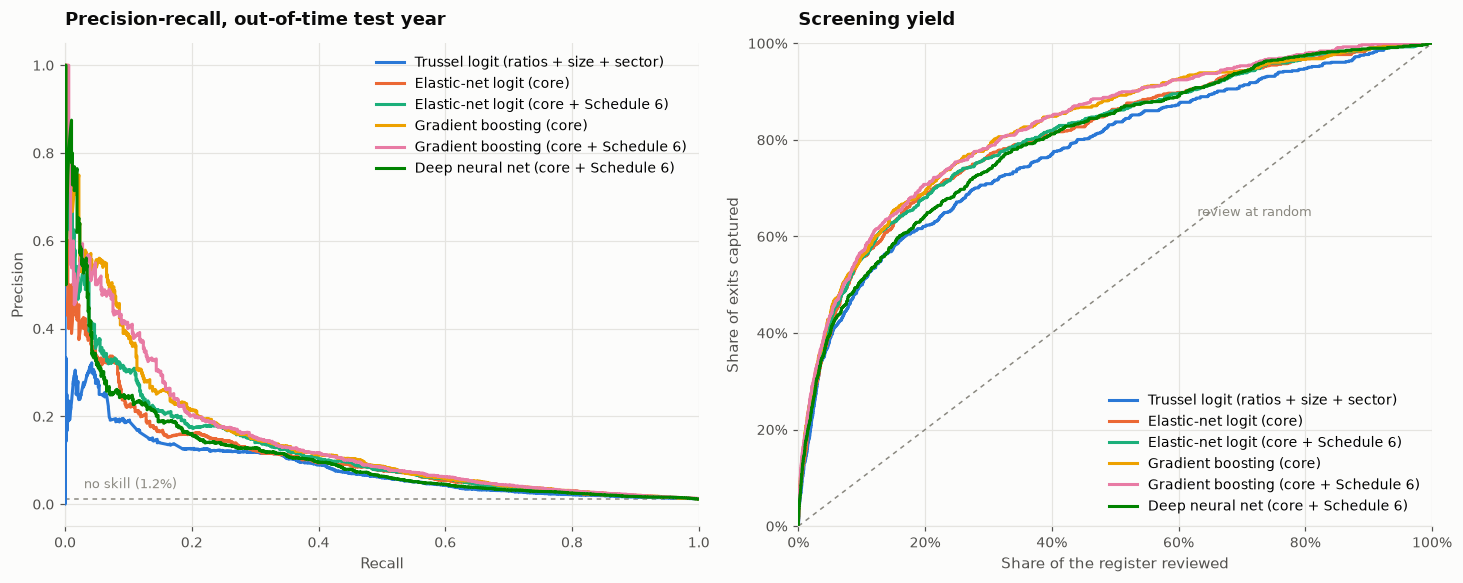

In [9]:
y_test = test["exit_next_year"].to_numpy()
risks = {model.spec.label: model.risk(test) for model in fitted.values()}

# Eight curves in one axes is unreadable, so the charts show the benchmark plus
# the core/+Schedule 6 pair from each family. The table above has all eight.
shown = ["trussel_2002", "extended_logit_core", "schedule_6_logit",
         "gradient_boosting_core", "schedule_6_gbm", "schedule_6_mlp"]
chart_risks = {fitted[k].spec.label: risks[fitted[k].spec.label] for k in shown}

fig, axes = plots.plt.subplots(1, 2, figsize=(13.4, 5.4))
plots.plot_pr_curves(y_test, chart_risks, ax=axes[0])
plots.plot_gains_curves(y_test, chart_risks, ax=axes[1])
fig.tight_layout();

## 5. Is the gain real?

Two paired bootstraps, on the two metrics that answer different questions.
ROC-AUC asks whether the whole ranking improved; average precision asks whether
it improved *where the positives are*, which at a 1.2% base rate is the question
that matters.

In [10]:
pairs = [
    ("schedule_6_logit", "extended_logit_core", "elastic-net logit"),
    ("schedule_6_gbm", "gradient_boosting_core", "gradient boosting"),
    ("schedule_6_mlp", "deep_neural_net_core", "deep neural net"),
]
rows = []
for richer, core, family in pairs:
    for metric_name, metric in [("roc_auc", roc_auc_score),
                                ("average_precision", average_precision_score)]:
        stats = bootstrap_metric_difference(
            y_test, fitted[richer].risk(test), fitted[core].risk(test),
            metric=metric, n_boot=500)
        rows.append({"family": family, "metric": metric_name,
                     "difference": stats["difference"],
                     "95% interval": f"[{stats['ci_low']:+.4f}, {stats['ci_high']:+.4f}]",
                     "p_worse": stats["p_worse"]})
pd.DataFrame(rows).set_index(["family", "metric"]).round(4)

difference        95% interval  p_worse
family            metric                                                    
elastic-net logit roc_auc                0.0013  [-0.0047, +0.0080]    0.320
                  average_precision      0.0157  [+0.0062, +0.0257]    0.000
gradient boosting roc_auc                0.0037  [-0.0041, +0.0115]    0.184
                  average_precision     -0.0004  [-0.0139, +0.0126]    0.564
deep neural net   roc_auc               -0.0082  [-0.0222, +0.0040]    0.912
                  average_precision     -0.0077  [-0.0230, +0.0061]    0.862

This is the central result of the notebook, and it is a split decision.

**For the elastic-net logit, the detailed return matters.** Average precision
rises from 0.108 to 0.124 — a 15% relative gain — and the bootstrap interval on
that difference sits clear of zero. Top-1% lift rises from 14.4x to 16.7x. The
AUC difference, by contrast, is indistinguishable from zero: the extra detail is
not reordering the whole register, it is sharpening the top of it. That is the
part a supervisor uses.

**For gradient boosting, it does not.** Average precision moves from 0.145 to
0.145. The AUC difference is positive but its interval spans zero. Ninety-seven
features do the work of fifty-one.

The reconciliation is in the next section, and it is not that the Schedule 6
lines are uninformative.

## 6. Why the tree gains nothing

Look at the last rung of the ladder. A model built from the detailed return plus
two size controls — no core ratios, an **almost disjoint set of inputs** —
reaches an average precision of 0.122 under the same gradient-boosting
configuration that gets 0.145 from the core set. The Schedule 6 lines are not
weak. They arrive at most of the same place by a different route.

That explains the split decision. Two feature sets that largely encode the same
underlying facts will not add to each other under a model flexible enough to
extract those facts from either one. A linear model is not that flexible: it
cannot represent "cash is low *relative to* what this organisation spends, and
falling" from totals alone, but handed `months_of_cash` and
`delta_cash_to_assets` it can. Gradient boosting constructs those interactions
itself, and so gains nothing when they are handed to it pre-computed.

Section 3b gives a second, more mechanical version of the same argument. The
new ratios mostly act as **thresholds** — below 1x interest coverage is risky,
above it nothing more is learned. A logit fed the raw totals cannot find that
breakpoint; fed `interest_coverage` it at least gets a monotone proxy for it. A
tree finds breakpoints by construction, in whatever variable it is given.

The practical implication is worth stating plainly, because it points the
opposite way from the obvious intuition:

> If you have a flexible model, you do not need the long form to triage well.
> The detailed return buys accuracy mainly for institutions constrained to
> simple, explainable, linear scoring — which, for a regulator publishing its
> methodology, may well be the binding constraint.

In [11]:
importance = permutation_importance_table(fitted["schedule_6_gbm"], test,
                                          "exit_next_year", n_repeats=5)
importance["group"] = np.where(importance["feature"].isin(SCHEDULE_6),
                               "Schedule 6", "core")
positive = importance.loc[importance["ap_drop_mean"] > 0]
print("share of total positive importance from Schedule 6 features: "
      f"{positive.loc[positive['group'] == 'Schedule 6', 'ap_drop_mean'].sum() / positive['ap_drop_mean'].sum():.1%}\n")
importance.head(18)[["feature", "group", "ap_drop_mean", "ap_drop_std"]].round(5)

share of total positive importance from Schedule 6 features: 23.5%



,feature,group,ap_drop_mean,ap_drop_std
5,log_total_assets,core,0.05051,0.00779
17,asset_growth,core,0.04172,0.00315
36,months_of_cash,core,0.02533,0.00301
6,log_total_revenue,core,0.01779,0.00210
24,share_receipted_gifts,core,0.01656,0.00388
97,delta_months_of_cash,Schedule 6,0.01288,0.00326
7,log_age,core,0.01018,0.00119
11,expense_coverage,core,0.00961,0.00096
18,expenditure_growth,core,0.00596,0.00135
94,delta_cash_to_assets,Schedule 6,0.00493,0.00283


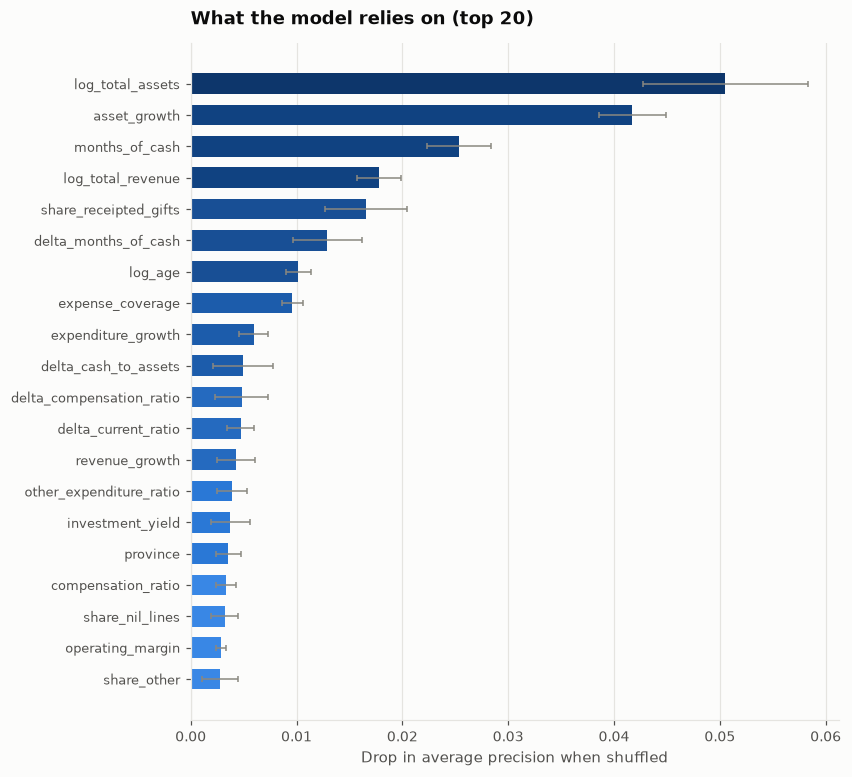

In [12]:
fig, ax = plots.plt.subplots(figsize=(7.6, 8.0))
plots.plot_permutation_importance(importance, top_n=20, ax=ax);

Schedule 6 features account for just under a quarter of the model's total
reliance, and the pattern among them is consistent: **the deltas outrank the
levels.** The three highest-ranked Schedule 6 features are all year-on-year
changes — `delta_months_of_cash`, `delta_cash_to_assets`, `delta_current_ratio`
— while the level ratios they are derived from mostly fall outside the top
twenty.

That is the same lesson as `03-model-results`, sharpened. What a charity's
balance sheet is *doing* predicts deregistration better than what it *is* — and
the detailed return's real contribution is not that it shows more of the balance
sheet, but that it shows more of the balance sheet *changing*.

The level ratios that do survive are not the ones a liquidity analysis would
nominate. `other_expenditure_ratio` — the share of spending a charity could not
fit into any of the thirteen named categories — outranks every itemised cost
line. That is less a cost-structure signal than a statement about how legible the
organisation's spending is, and it rhymes with `share_nil_lines` doing well in
the core set: both reward charities whose activity maps cleanly onto the form.

## 7. Calibration on the restricted sample

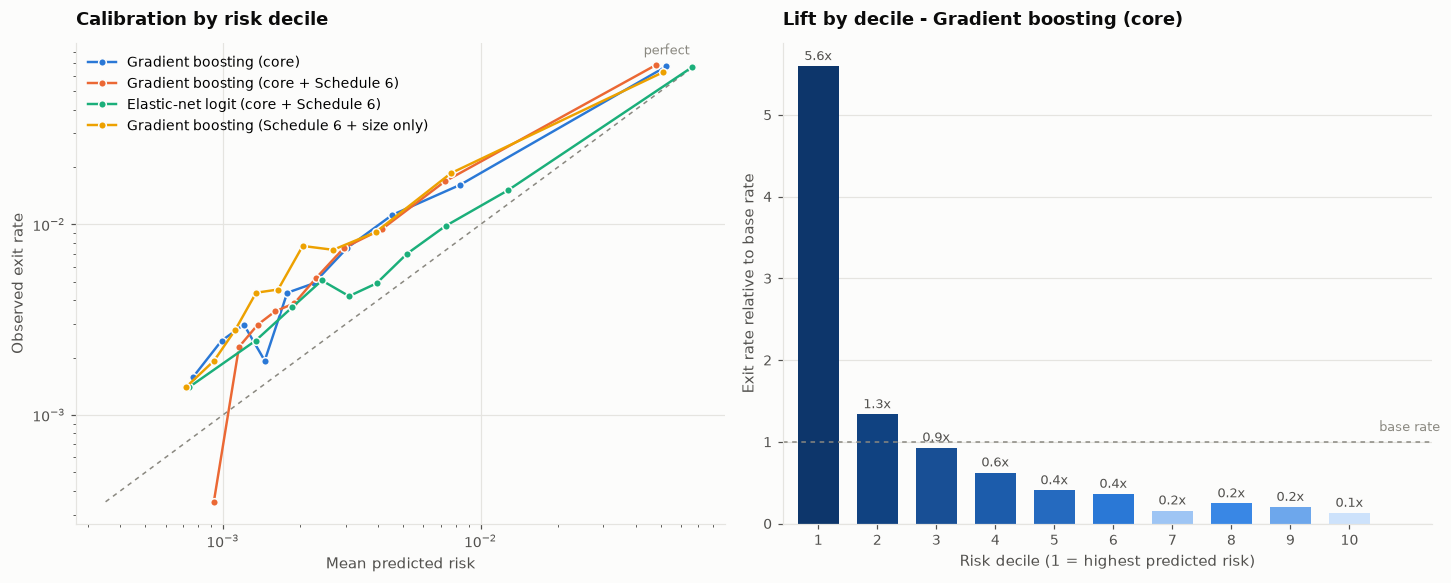

In [13]:
top = list(results.index[:4])
calibrations = {fitted[k].spec.label: calibration_table(y_test, fitted[k].risk(test))
                for k in top}
best = results.index[0]
lift = lift_table(y_test, fitted[best].risk(test))

fig, axes = plots.plt.subplots(1, 2, figsize=(13.4, 5.4))
plots.plot_calibration(calibrations, ax=axes[0])
plots.plot_decile_lift(lift, ax=axes[1], title=f"Lift by decile - {fitted[best].spec.label}")
fig.tight_layout();

In [14]:
lift.style.format({"n": "{:,.0f}", "n_events": "{:,.0f}", "event_rate": "{:.2%}",
                   "mean_predicted": "{:.2%}", "lift": "{:.2f}x",
                   "cumulative_recall": "{:.1%}"})

,n,n_events,event_rate,mean_predicted,lift,cumulative_recall
decile,,,,,,
1,"5,709",385,6.74%,5.25%,5.60x,56.0%
2,"5,709",92,1.61%,0.83%,1.34x,69.3%
3,"5,708",64,1.12%,0.45%,0.93x,78.6%
4,"5,709",43,0.75%,0.30%,0.62x,84.9%
5,"5,709",28,0.49%,0.23%,0.41x,89.0%
6,"5,708",25,0.44%,0.18%,0.36x,92.6%
7,"5,709",11,0.19%,0.15%,0.16x,94.2%
8,"5,708",17,0.30%,0.12%,0.25x,96.7%
9,"5,709",14,0.25%,0.10%,0.20x,98.7%


## 8. Hyperparameter robustness

The conclusion in section 5 rests on the two gradient-boosting rungs being
tuned alike. To check that the richer feature set is not simply being starved of
capacity, here is the sweep the shared configuration was chosen from — run on
the richer model, where extra capacity would show up if it helped.

In [15]:
from charity_risk.models import ModelSpec, build_gbm_pipeline, schedule_6_features
from charity_risk.evaluate import fit_spec

numeric, categorical = schedule_6_features()
grid = {
    "shallow (full-population default)": dict(max_leaf_nodes=31, min_samples_leaf=100,
                                              learning_rate=0.05, max_iter=400),
    "deeper (used above)": dict(max_leaf_nodes=63, min_samples_leaf=50,
                                learning_rate=0.03, max_iter=900),
    "wider": dict(max_leaf_nodes=127, min_samples_leaf=40, learning_rate=0.03,
                  max_iter=900, l2_regularization=3.0),
}
rows = []
for name, params in grid.items():
    spec = ModelSpec(name=name, label=name, numeric=tuple(numeric),
                     categorical=tuple(categorical),
                     factory=lambda n, c, p=params: build_gbm_pipeline(n, c, **p))
    risk = fit_spec(spec, train, "exit_next_year").risk(test)
    rows.append({"configuration": name, "roc_auc": roc_auc_score(y_test, risk),
                 "average_precision": average_precision_score(y_test, risk)})
pd.DataFrame(rows).set_index("configuration").round(4)

shallow (full-population default): features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


deeper (used above): features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


wider: features entirely missing in the training sample, neutralised to zero: ['revenue_growth_volatility']


,roc_auc,average_precision
configuration,,
shallow (full-population default),0.8302,0.1436
deeper (used above),0.8323,0.1449
wider,0.8315,0.1391


Capacity is not the binding constraint: the richer model's average precision
varies by about 0.006 across a fourfold range of tree capacity, far less than
the 0.037 gap between the linear and tree families. The detail genuinely is
redundant with what the tree extracts, rather than under-fitted.

## 9. What this notebook establishes

**Established.**

* The detailed return carries substantial signal from an almost disjoint set of
  inputs. Under gradient boosting, Schedule 6 features plus two size controls
  reach an average precision of 0.122 against 0.145 for the entire core set —
  most of the way there, using different lines of the same return.
* That signal is worth a **15% gain in average precision for a linear model**,
  with the bootstrap interval clear of zero, concentrated at the top of the
  ranking rather than spread across it (the AUC difference is not
  distinguishable from zero).
* It is worth **nothing to gradient boosting**, across a fourfold range of tree
  capacity. The itemised detail is a substitute for model flexibility, not a
  complement to it.
* Within the detailed return, **changes beat levels**. The three highest-ranked
  Schedule 6 features are all year-on-year deltas.
* **A reported zero beats the ratio it makes undefined.** Charities reporting no
  current liabilities, no capital assets or no interest exit at up to twice the
  sample rate — more than any band of the ratio itself. These are reported
  zeros, not missing data, so they are carried as explicit `no_*` indicators.
  The detailed return identifies dormancy through the lines a charity reports
  nothing on.
* **Where they are defined, the new ratios are threshold tests.** Interest
  coverage below 1x carries a 3.4x higher exit rate than at or above 1x, with no
  further gradient above the threshold. That shape is exactly what a linear
  model cannot express and a tree captures for free — a second, mechanical
  reason the linear model gains from features that gradient boosting does not.
* **The disbursement quota indicator is not a compliance signal.** Only the
  extreme tail (below a tenth of the required minimum) is elevated; the band
  that actually fails the statutory test sits below the sample exit rate. It
  identifies dormant organisations holding property, not charities being revoked
  for missing their quota.

**Not established.**

* *Nothing here transfers to the excluded population.* Section D filers are
  smaller, exit more than twice as often, and are not represented at all. This
  model must not be used to score them, and its metrics say nothing about how it
  would do if it could.
* *The sample is selected on the outcome's strongest predictor.* Every number in
  this notebook is conditional on being large enough to file the long form.
  Comparisons with `03-model-results` are invalid in both directions.
* *One training year, one test year*, as throughout the project — and here with
  roughly half as many positive cases, so the intervals are correspondingly
  wider.
* *`tier_downgrade` is unavailable by construction*, so the restricted model is
  denied one of the core set's useful signals. Part of the core model's
  respectable showing here is achieved without it.
* *The disbursement quota rate is applied at a flat 3.5%.* It rose to 5% on the
  portion of the base above $1M for fiscal periods beginning on or after 1
  January 2023, which touches almost nothing in a 2019-2023 window but would
  matter if the panel were extended forward.